# **1-Import of Main libraries & Seeds**

In [14]:
!pip install ultralytics

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import os
import tensorflow as tf
import random
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.model_selection import train_test_split
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay , classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout , GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
from ultralytics import YOLO
import os
import glob
from tqdm.notebook import tqdm
from google.colab import drive

In [16]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
train_images_path = "/content/drive/MyDrive/Image-Captioning/dataset_split/train/images"
train_labels_path = "/content/drive/MyDrive/Image-Captioning/dataset_split/train/labels"

val_images_path = "/content/drive/MyDrive/Image-Captioning/dataset_split/val/images"
val_labels_path = "/content/drive/MyDrive/Image-Captioning/dataset_split/val/labels"

test_images_path = "/content/drive/MyDrive/Image-Captioning/dataset_split/test/images"
test_labels_path = "/content/drive/MyDrive/Image-Captioning/dataset_split/test/labels"

In [18]:
import os

print("train images exists:", os.path.exists(train_images_path))
print("train labels exists:", os.path.exists(train_labels_path))
print("val images exists:", os.path.exists(val_images_path))
print("val labels exists:", os.path.exists(val_labels_path))
print("test images exists:", os.path.exists(test_images_path))
print("test labels exists:", os.path.exists(test_labels_path))

train images exists: True
train labels exists: True
val images exists: True
val labels exists: True
test images exists: True
test labels exists: True


# **2-Visualize Actual Boundaries**

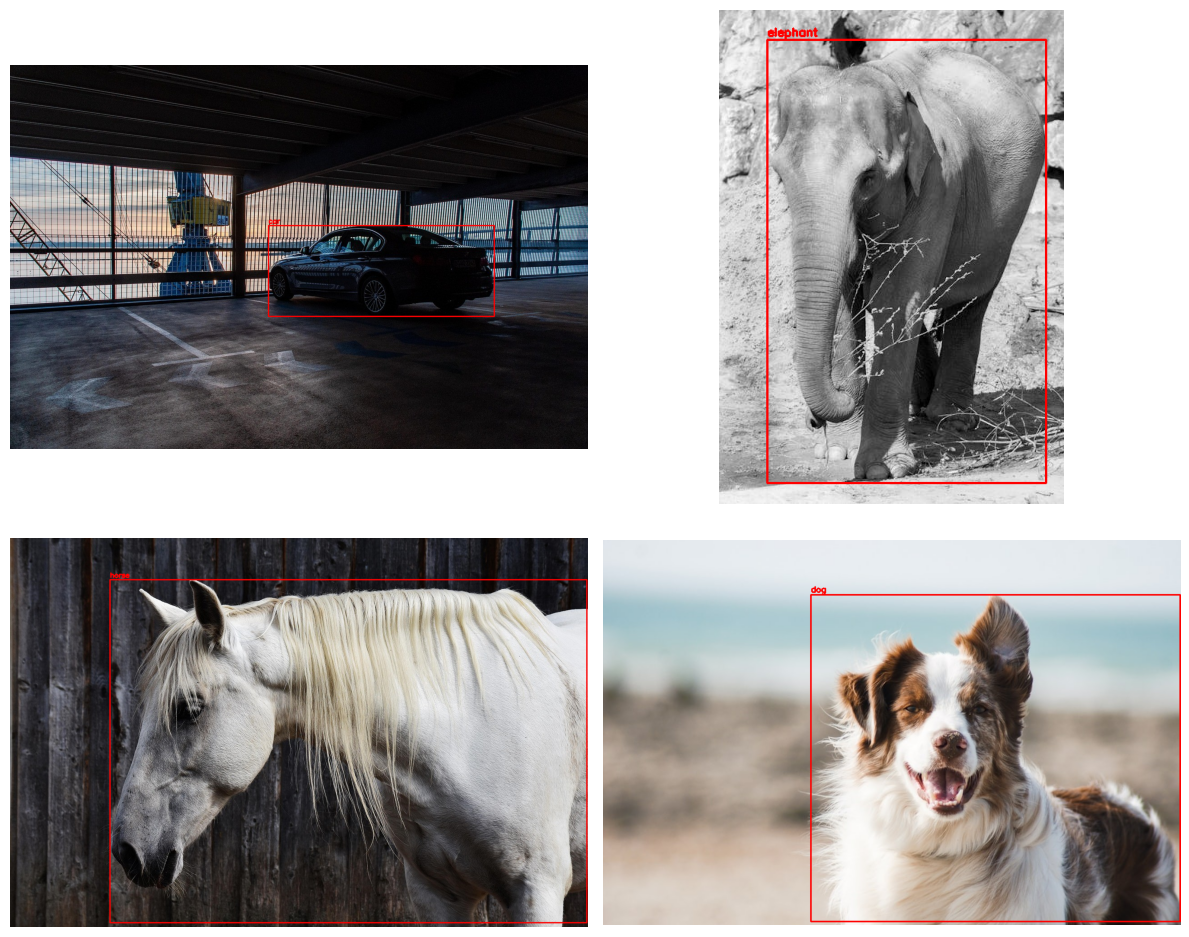

In [19]:
images_path = "/content/drive/MyDrive/Image-Captioning/dataset_split/train/images"
labels_path = "/content/drive/MyDrive/Image-Captioning/dataset_split/train/labels"



class_names = [
    "person", "bicycle", "car", "motorcycle", "airplane",
    "bus", "train", "truck", "boat", "traffic light",
    "stop sign", "bench",
    "bird", "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra",
    "snowboard", "sports ball",
    "cup", "chair",
    "tv", "laptop", "remote",
    "book", "clock"
]
image_files = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.png'))]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, img_file_name in zip(axes.flatten(), image_files[:4]):
    img_file = os.path.join(images_path, img_file_name)
    label_file = os.path.join(labels_path, os.path.splitext(img_file_name)[0] + ".txt")

    img = cv2.imread(img_file)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if os.path.exists(label_file):
        with open(label_file, "r") as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                class_id = int(parts[0])
                x_center, y_center, bw, bh = map(float, parts[1:])
                x1 = int((x_center - bw/2) * w)
                y1 = int((y_center - bh/2) * h)
                x2 = int((x_center + bw/2) * w)
                y2 = int((y_center + bh/2) * h)
                color = (255, 0, 0)
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                cv2.putText(img, class_names[class_id], (x1, y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()


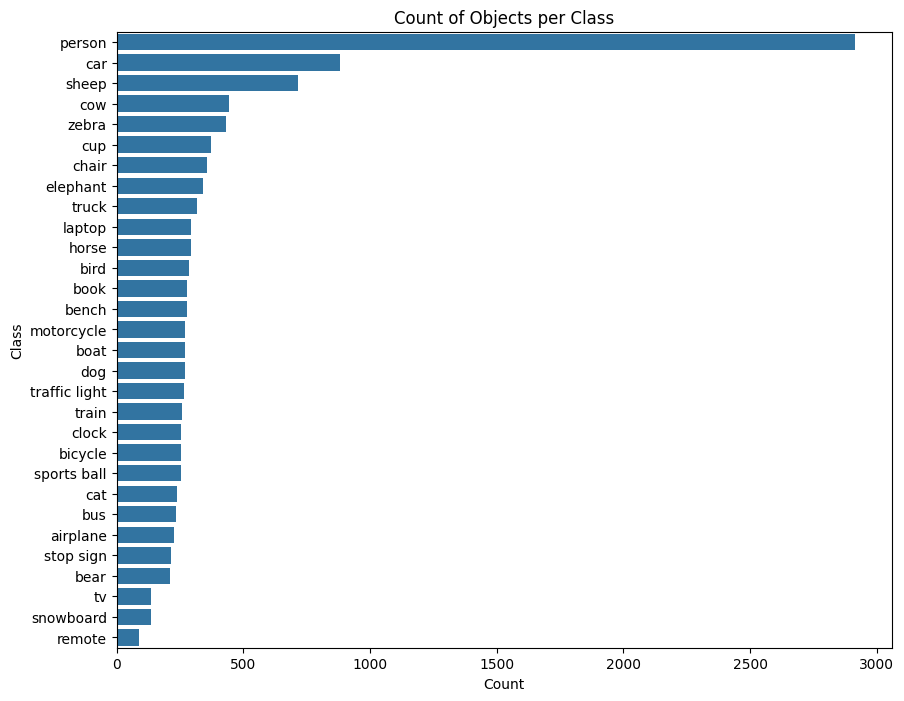

In [41]:
all_classes = []

for label_file in os.listdir(labels_path):
    if label_file.endswith(".txt"):
        with open(os.path.join(labels_path, label_file), "r") as f:
            lines = f.readlines()
            for line in lines:
                class_id = int(line.strip().split()[0])
                all_classes.append(class_names[class_id])

df = pd.DataFrame({"class": all_classes})

class_order = df["class"].value_counts().index

plt.figure(figsize=(10, 8))
sns.countplot(data=df, y="class", order=class_order)
plt.title("Count of Objects per Class")
plt.xlabel("Count")
plt.ylabel("Class")
plt.show()

# **4-Yaml FIle**

In [21]:
import os
import yaml

classes = [
    "person", "bicycle", "car", "motorcycle", "airplane",
    "bus", "train", "truck", "boat", "traffic light",
    "stop sign", "bench",
    "bird", "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra",
    "snowboard", "sports ball",
    "cup", "chair",
    "tv", "laptop", "remote",
    "book", "clock"
]

data_yaml = {
    'train': '/content/drive/MyDrive/Image-Captioning/dataset_split/train/images',
    'val': '/content/drive/MyDrive/Image-Captioning/dataset_split/val/images',
    'test': '/content/drive/MyDrive/Image-Captioning/dataset_split/test/images',
    'nc': len(classes),
    'names': classes
}

yaml_path = "/content/drive/MyDrive/Image-Captioning/dataset_split/data.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(f"YAML saved at: {yaml_path}")


YAML saved at: /content/drive/MyDrive/Image-Captioning/dataset_split/data.yaml


In [22]:
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

print(data)

{'train': '/content/drive/MyDrive/Image-Captioning/dataset_split/train/images', 'val': '/content/drive/MyDrive/Image-Captioning/dataset_split/val/images', 'test': '/content/drive/MyDrive/Image-Captioning/dataset_split/test/images', 'nc': 30, 'names': ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'stop sign', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'snowboard', 'sports ball', 'cup', 'chair', 'tv', 'laptop', 'remote', 'book', 'clock']}


# **5-Using yolov8m Model**

In [23]:
RANDOM_SEED = 0
IOU_THRESHOLD = 0.7
CONF_THRESHOLD = 0.25
INPUT_SIZE = 224
PATIENCE = 5
EPOCHS = 50

config = {
    'batch': 32,
    'optimizer': "AdamW",
    'lr0': 0.004,
    'lrf': 0.02559244954708425,
    'weight_decay': 0.0005,
    'momentum': 0.9,
    'dropout': 0.05
}

model = YOLO('yolov8m.pt')

results_head = model.train(
    data=yaml_path,
    epochs=EPOCHS,
    batch=config['batch'],
    optimizer=config['optimizer'],
    lr0=config['lr0'],
    lrf=config['lrf'],
    weight_decay=config['weight_decay'],
    momentum=config['momentum'],
    dropout=config['dropout'],
    device=0,
    project='rdd_baseline',
    name='run_head',
    exist_ok=True,
    patience=PATIENCE,
    save=True,
    visualize=False,
    amp=True,
    seed=RANDOM_SEED,
    verbose=True,
    augment=True,
    imgsz=INPUT_SIZE,
    mosaic=0.0,
    mixup=0.0,
    fliplr=0.5,
    degrees=1.0,
    translate=0.03,
    scale=0.15,
    perspective=0.0005
)


Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Image-Captioning/dataset_split/data.yaml, degrees=1.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.05, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.004, lrf=0.02559244954708425, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.9, mosaic=0.0, multi_scale=0.0, name=run_head, nbs=64, nms=False, opset=None, optimize=False, o

# **6-Model Evaluation**

In [24]:
metrics = model.val(
    data=yaml_path,
    imgsz=224,
    batch=64,
    split='test'
)

print("Key Performance Indicators:")
print(f"  Precision (P): {metrics.results_dict['metrics/precision(B)']: .4f}")
print(f"  Recall (R): {metrics.results_dict['metrics/recall(B)']: .4f}")
print(f"  mAP50: {metrics.results_dict['metrics/mAP50(B)']: .4f}")
print(f"  mAP50-95: {metrics.results_dict['metrics/mAP50-95(B)']: .4f}")

print("Model evaluation on test set completed.")

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,857,130 parameters, 0 gradients, 78.8 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 89.0±67.3 MB/s, size: 246.8 KB)
val: Scanning /content/drive/MyDrive/Image-Captioning/dataset_split/test/labels.cache... 962 images, 151 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 962/962 252.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.0it/s 15.5s
                   all        962       1493      0.682      0.587      0.629      0.489
                person        201        318      0.783      0.683      0.739      0.502
               bicycle         31         37      0.571       0.54      0.614      0.483
                   car         51        135       0.69      0.452      0.513      0.312
            motorcycle         41         44      0.745       0.75       0.77      0.618
         

# **7-Model Experment**

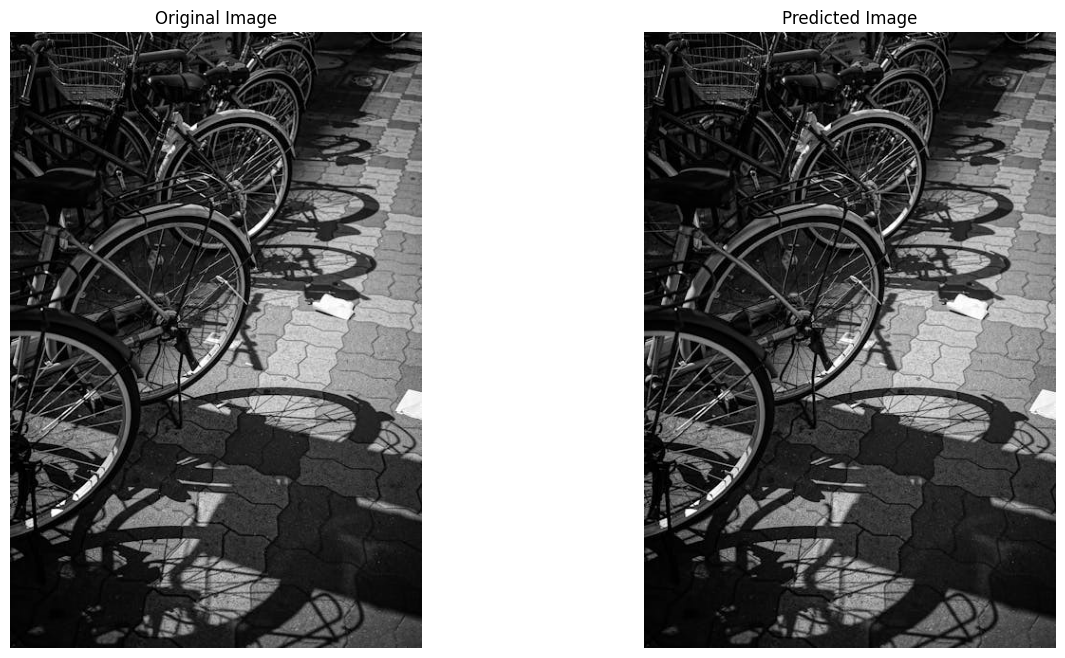

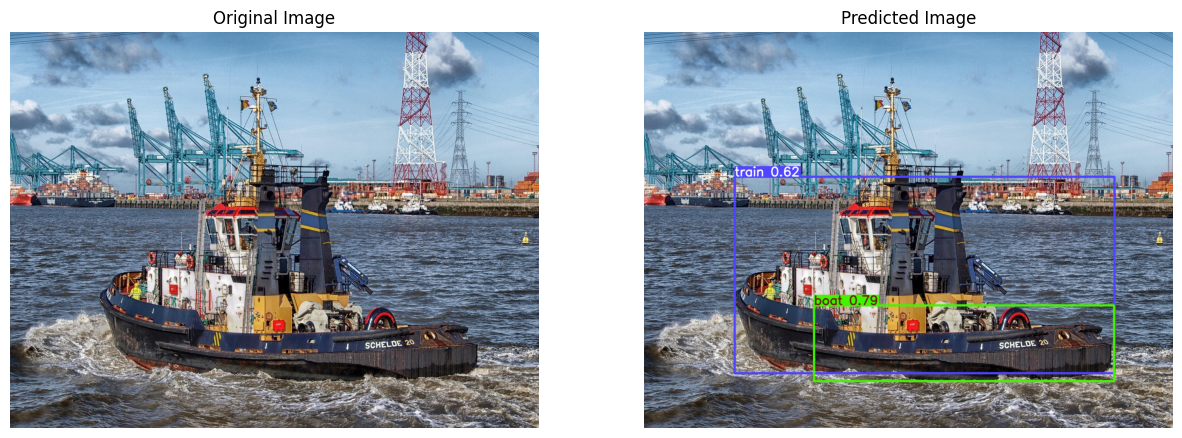

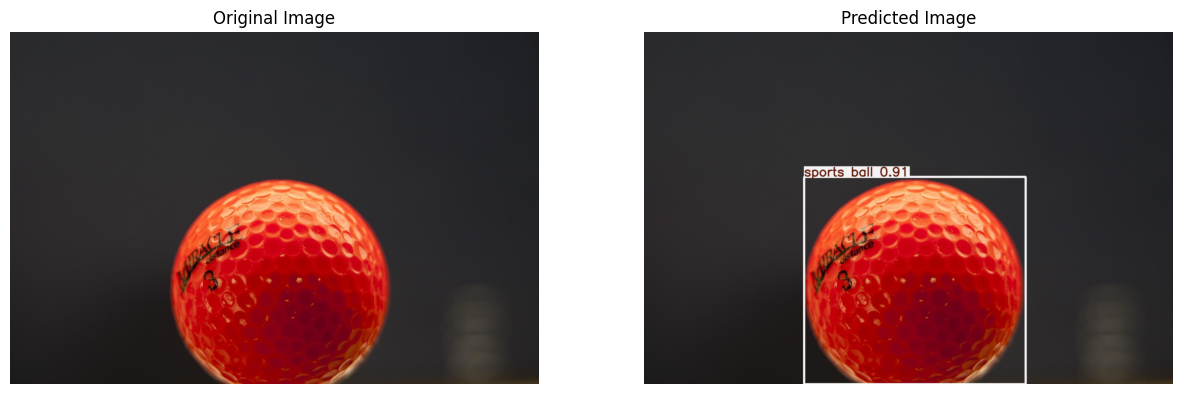

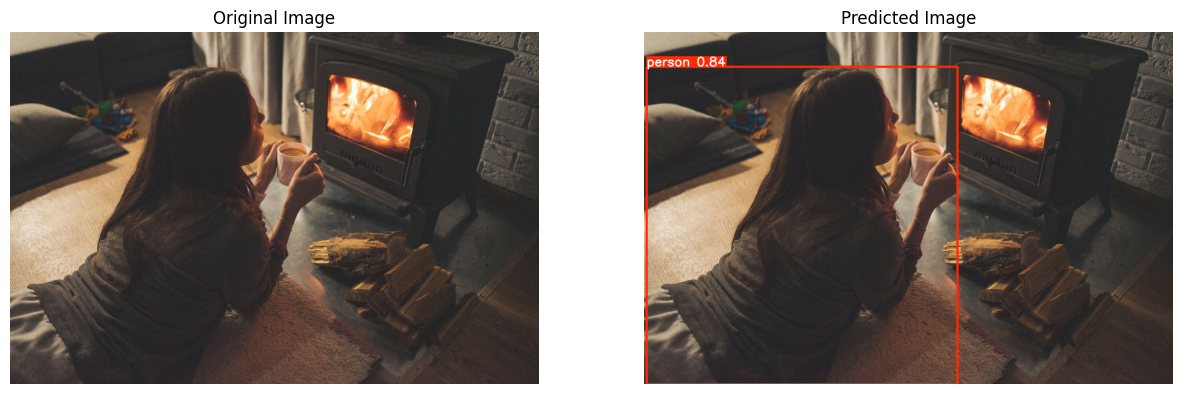

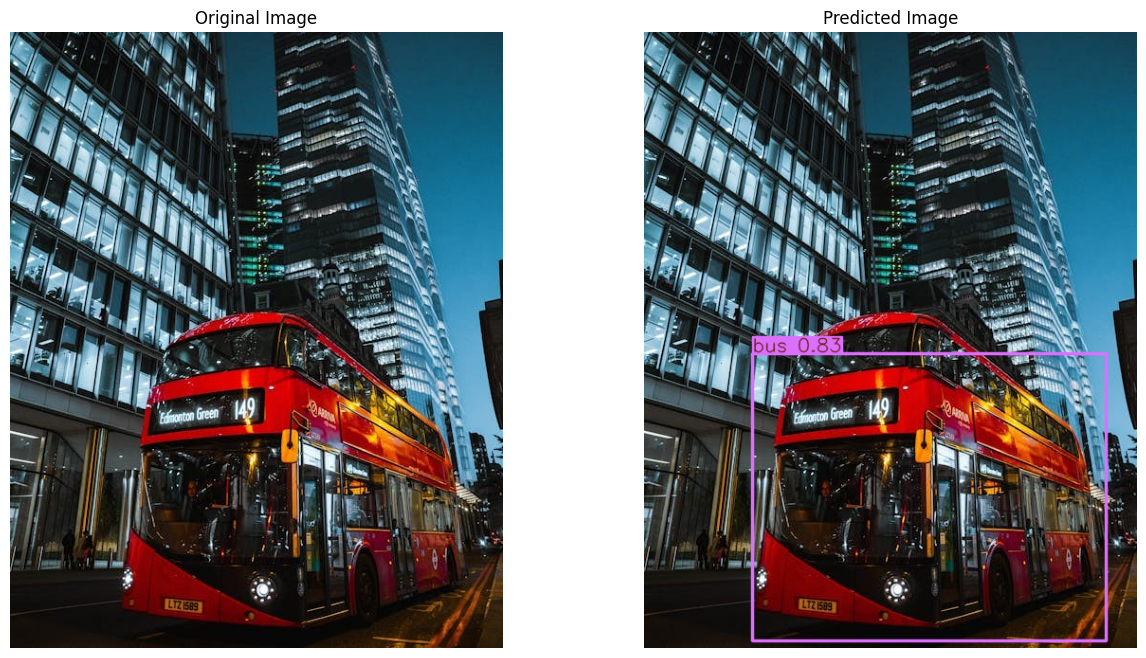

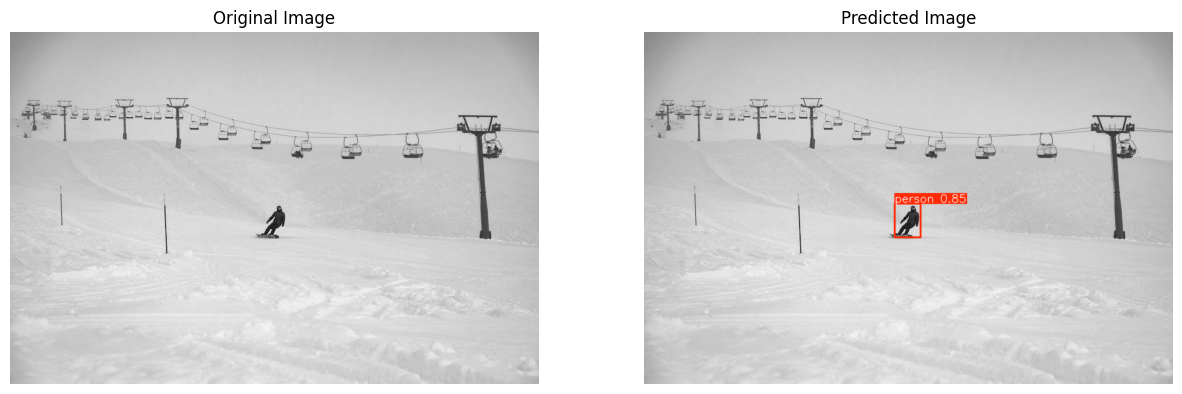

In [40]:
import cv2
import random
import glob
import matplotlib.pyplot as plt
from ultralytics import YOLO

random.seed(102)

model = YOLO('/content/runs/detect/rdd_baseline/run_head/weights/best.pt')

dir_path = "/content/drive/MyDrive/Image-Captioning/dataset_split/test/images"
all_images = glob.glob(f"{dir_path}/*.jpg")

sample_count = min(6, len(all_images))
sample_images = random.sample(all_images, sample_count)

for img_path in sample_images:
    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not read image: {img_path}")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = model(img_rgb, conf=0.50, verbose=False)

    pred_img = results[0].plot()

    plt.figure(figsize=(15, 8))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(pred_img)
    plt.title("Predicted Image")
    plt.axis('off')

    plt.show()